In [1]:
#Never stop to roll de dice

#### БЕНЗИН!

## Задача 2. 12 баллов
Дообучите одну из следующих моделей генерировать анекдоты на русском языке:
- [Qwen-3-0.6B](https://huggingface.co/Qwen/Qwen3-0.6B)
- [Qwen-2.5-0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B)
- [gemma-3-270m](https://huggingface.co/google/gemma-3-270m)
- [SmolLM-360M](https://huggingface.co/HuggingFaceTB/SmolLM2-360M)

Для этого можете использовать SFT/RL. В качестве исходной модели можно брать Instruct-версию чекпойнта, за базовую версию (только Pretrain) вы получите +1 доп.балл.

Для сдачи этого задания вам необходимо подготовить файл со сгенерированными анекдотами в форммате txt, анекдоты должны находиться на отдельных строках.
Сдача задания будет проходить в виде соревнования-арены в специальном боте. Вам необходимо будет отправить подготовленный файл боту.Внимание! Можно отправить (успешно) только один файл! После небольшой проверки (премодерации) он будет добавлен в пул соревнующихся моделей.
Во время соревнования вы будете получать пары предсказаний и должны будете проголосовать за лучший из них. По количеству голосов будет определяться финальный рейтинг. Чем больше вы сравните анекдотов, тем более честным он будет :)
Соревнование закроется за 2 дня до зачета, защита этого задания будет включать только проверку ноутбуков заочно (без общения).
Для проверки вы должны закоммитить ноутбук c логами генерации, а также скрипты/ноутбуки, использованные для дообучения модели. 

Топ 25% получит +4 балла, топ-50% + 3 балла, топ-75% +1 балл


In [48]:
import pandas as pd
import random

from transformers import AutoTokenizer, AutoModelForCausalLM
import csv
import matplotlib.pyplot as plt
import os
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

In [3]:
with open("prefixes.txt", encoding="utf-8") as f:
    data = [line.rstrip().split(" ", 1) for line in f if line.strip()]

df = pd.DataFrame(data, columns=["index_id", "text"])
df["index_id"] = df["index_id"].astype(int)

df

,index_id,text
0,1,Идёт мужик по лесу
1,2,Встречаются два друга
2,3,Приходят мужик в бар
3,4,Жена говорит мужу
4,5,"Приходят альфа, бета и гамма в бар"
...,...,...
70,76,Встречаются overfitting и underfitting
71,80,Идёт по дому кошка
72,81,Я из тех людей
73,82,- Я нормальный.


In [4]:
#hf_model_name = "google/gemma-3-270m"
#hf_model_name = "Qwen/Qwen3-0.6B"
#hf_model_name = "Qwen/Qwen2.5-0.5B"
#hf_model_name = "HuggingFaceTB/SmolLM2-360M"

#hf_model_name = "google/gemma-3-270m-it"
#hf_model_name = "HuggingFaceTB/SmolLM2-360M-Instruct"

hf_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
model = AutoModelForCausalLM.from_pretrained(
    hf_model_name,
)

prompt = "Идёт мужик по лесу"
inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=64,
    temperature=1.2,
    top_p=0.95,
    top_k=50,
    
    repetition_penalty=1.15,
    no_repeat_ngram_size=3,
    
    do_sample=True
)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(answer)

with open("/home/kalisto/Documents/spbu_dl_2025/data/full_jokes.txt", encoding="utf-8") as f:
    jokes_data = [{"text": line.rstrip()} for line in f if line.strip()]

Идёт мужик по лесу, у него есть двое детей, их папа работает за кварталом на службе.
Когда он идет на работу, они включают в общую длительность времени движения на работу с 0.6 раз (например: "Размаха мужика на работу:


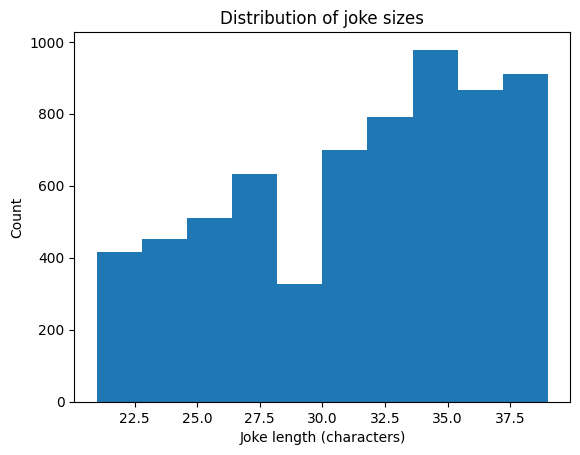

6585


['Какой бизнес - такой и ланч.',
 'Я женщина честная поэтому и дорогая.',
 '- Вы любите женщин? - Местами...',
 '"... Всем оставаться на своих местах!"',
 '(в соавторстве с К.Прутковым)',
 'Из серии коротких... -Изя, вы еврей?',
 '- Больно? -ДА! -Высунуть? - НЕТ!',
 '- У солдата выходной - пигалицы в ряд!',
 '" Я не грустный, я трезвый.',
 'Я не грустный, я еврей.']

In [5]:
with open("/home/kalisto/Documents/spbu_dl_2025/data/full_jokes.txt", encoding="utf-8") as f:
    content = f.read()

jokes_data = [
    j.strip().replace("\n", " ")
    for j in content.split("\n\n")
    if j.strip() and ":" not in j
]

jokes_data = [
    j for j in jokes_data
    if all("путин" not in word.lower() for word in j.split())
    and 20 < len(j) < 50
]


jokes1 = [joke for joke in jokes_data if 10 < len(joke) < 40]
lengths = [len(joke) for joke in jokes1]

plt.figure()
plt.hist(lengths, bins=10)
plt.xlabel("Joke length (characters)")
plt.ylabel("Count")
plt.title("Distribution of joke sizes")
plt.show()
print(len(jokes1))
jokes1[:10]


In [6]:
rows = []

with open("/home/kalisto/Documents/spbu_dl_2025/data/dataset_jokes.csv", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        text = row["text"].replace("\r\n", " ").replace("\n", " ").strip()
        if text and 10 < len(text) <= 40:
            row["text"] = text
            rows.append(row)


df = pd.DataFrame(rows)

texts_list = df["text"].tolist()

jokes2 = [
    j for j in texts_list
    if all("путин" not in word.lower() for word in j.split())
    and 20 < len(j) < 50
]
jokes2[:10]

['Моя фамилия - полковник Пилюгин!',
 'Ну вот и все... Сказал догорев фитилек.',
 '- Официант, обнулите счет, пожалуйста!',
 'Утро к вечеру намудрило.',
 'Для начинающих - вазелин с новокаином!',
 'Каков период полураспада оливье?',
 'Не яйца красят человека, а человек яйца.',
 'Йопти - это русский снежный человек.',
 'Нет, вы умом не блещете, вы им рябите!',
 '- Слава Богу дозвонился!- Какой Слава?']

In [30]:
df

,theme,text,rating
0,pro-sudey,"Судья: - Свидетель, вы женаты? Обвиняемый: - ...",2
1,pro-studentov,"- Тому, кто пойдет первым к доске, поставлю н...",17
2,pro-sisadminov,Из дневника админа: Перечитывал логи много дум...,12
3,pro-sisadminov,Как сильно обидеть админа? Сказать ему: Заходи...,57
4,pro-poruchika-rgevskogo,"""Будите ли ,вы, утром жену, Ржевский?"" Ржевск...",8
...,...,...,...
50769,raznie,Часовой - это труп Завернутый в тулуп Выстав...,0
50770,raznie,"Жили мы бедно, хлеба не было, поэтому масло ма...",0
50771,raznie,Удаленный доступ к сети - это когда доступ уд...,0
50772,raznie,В каждом из нас спит гений и с каждым днем вс...,0


In [62]:
rows = []

with open("/home/kalisto/Documents/spbu_dl_2025/data/jokes.csv", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        text = row["text"].replace("\r\n", " ").replace("\n", " ").strip()
        if text and 10 < len(text) <= 70 and row["theme"] not in ["pro-putina", "pro-sport-pro-futbol", "pro-detey", "pro-armiu", "pro-evreev", "pro-sudey", "pro-poruchika-rgevskogo", "politicheskie", "pro-buhgalterov", "pro-vovochku", "pro-givotnih"] and int(row["rating"]) >= 0:
            row["text"] = text
            rows.append(row)


df = pd.DataFrame(rows)
jokes3 = df["text"].tolist()
random.shuffle(jokes3)
jokes3[:50]


['Сколько книг ни читай, а императором не станешь. Мао.',
 'Майонез "Загадочный"  срок годности указан на дне банки.',
 'Интеллегентные люди дамам вафли не предлагают...',
 '- И все-таки оно вертится! - сказал навозный жук.',
 'Показать товар лицом о стол.  Sah',
 'Не рой другому яму, чтобы он не использовал ее как окоп.',
 'Женщина должна быть одета так, чтобы ее было приятно раздевать!!!!!',
 'Отшумели летние долги , но сказала осень - зиму жди . (Д.Вернер)',
 'Ничего так не согревает душу, как холодное пиво...',
 'Любимый ответ еврея : - А судьи кто?',
 'Влад:  женщина в серверной, равноценна женщине на корабле !',
 'Устал... Уже войти не выйдет',
 'Любя, не бойся шевелиться!',
 'Не верить в истины - еще не повод отказываться от вина.',
 'того, кто рано встает, пи""!ят те, кто поздно ложится...',
 'Тяжело в учении? Легко въебу!',
 'Мечта импотента - натянуть хоть простыню по уши...  ©амо приползло...',
 'Улыбайтесь чаще - ШЕФ ЛЮБИТ ИДИОТОВ!',
 'Гармонично недоразвитый че

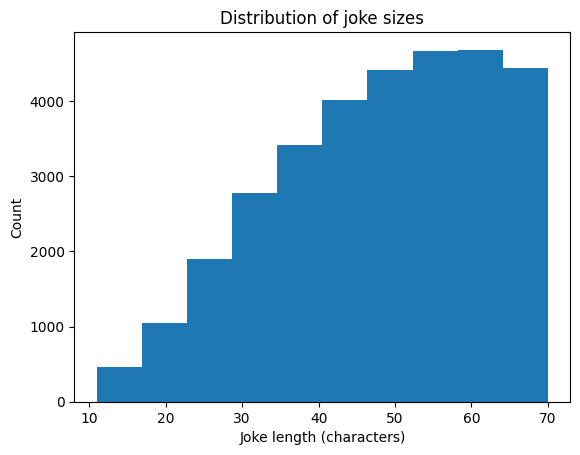

In [64]:
lengths = [len(joke) for joke in jokes3]

plt.figure()
plt.hist(lengths, bins=10)
plt.xlabel("Joke length (characters)")
plt.ylabel("Count")
plt.title("Distribution of joke sizes")
plt.show()

In [86]:
#jokes = list(dict.fromkeys(jokes1 + jokes2 + jokes3))
jokes = list(dict.fromkeys(jokes3))
print(len(jokes1))
print(len(jokes2))
print(len(jokes3))
print(len(jokes))
with open("/home/kalisto/Documents/spbu_dl_2025/data/full_jokes_cleaned.txt", "w", encoding="utf-8") as f:
    for joke in jokes:
        f.write(joke + "\n")


6585
3721
31830
31772


In [156]:

os.environ["WANDB_DISABLED"] = "true"

hf_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(hf_model_name)

print("\nLoading base model...")
model = AutoModelForCausalLM.from_pretrained(
    hf_model_name,
    torch_dtype=torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

print("Setting up LoRA...")
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

print("\nLoading jokes...")
jokes_file = "/home/kalisto/Documents/spbu_dl_2025/data/full_jokes_cleaned.txt"

if not os.path.exists(jokes_file):
    print(f"\nERROR: Please run clean_jokes_data.py first!")
    print(f"Expected file: {jokes_file}")
    exit(1)

with open(jokes_file, encoding="utf-8") as f:
    jokes_data = [{"text": line.strip()} for line in f if line.strip()]
    jokes_data = jokes_data[:1000]

print(f"Loaded {len(jokes_data)} jokes")

def format_joke(example):
    text = f"<|im_start|>assistant\n{example['text']}<|im_end|>"
    return {"formatted_text": text}

dataset = Dataset.from_list(jokes_data)
dataset = dataset.map(format_joke)

split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Tokenize
def tokenize_function(examples):
    return tokenizer(
        examples["formatted_text"],
        truncation=True,
        max_length=256,
        padding="max_length",
    )

print("\nTokenizing...")
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)
tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

training_args = TrainingArguments(
    output_dir="/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora",
    num_train_epochs=6,
    learning_rate=1e-4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=20,
    eval_steps=50,
    #eval_steps=2000,
    save_steps=2000,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    fp16=False,
    report_to="none",
    logging_dir="./logs",
    logging_first_step=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

try:
    trainer.train()
except Exception as e:
    print(f"\n\nError during training: {e}")
    exit(1)

# Save LoRA adapter
model.save_pretrained("/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final")
tokenizer.save_pretrained("/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final")


Loading base model...
Setting up LoRA...
trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359

Loading jokes...
Loaded 1000 jokes


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Training samples: 900
Validation samples: 100

Tokenizing...


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Step,Training Loss,Validation Loss
50,4.573700,3.448076
100,2.915200,3.055040
150,2.928100,3.033865
200,2.954300,3.010486
250,2.889200,3.005105
300,2.684100,2.998557
350,2.787100,3.001693
400,2.621400,3.009057
450,2.738700,3.005031
500,2.602700,3.022758


('/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/tokenizer_config.json',
 '/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/special_tokens_map.json',
 '/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/chat_template.jinja',
 '/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/vocab.json',
 '/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/merges.txt',
 '/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/added_tokens.json',
 '/home/kalisto/Documents/spbu_dl_2025/data/qwen-jokes-lora/final/tokenizer.json')

In [213]:
model.eval()
prompt = "<|im_start|>assistant\nЕсть только одна система:"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

answers = []
with torch.no_grad():
    for _ in range(15):
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=1.2,
            top_p=0.2,
            top_k=50,
            pad_token_id=tokenizer.pad_token_id,
        )
        answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
        answers.append(answer)

for i, ans in enumerate(answers, 1):
    lines = ans.split("\n")
    if len(lines) > 1:
        print(lines[1])


Есть только одна система: система волшебства.
Есть только одна система: сексуальная система.
Есть только одна система: "Собери все, что не везет".
Есть только одна система: "Помни, что я помню".
Есть только одна система: "Самоубеждение"
Есть только одна система: несогласенея, несогласно.
Есть только одна система: "Сколько денег ты даришь, то они будут возвращать".
Есть только одна система: несчастье - это возможность счастия.
Есть только одна система: система жизни.
Есть только одна система: симпатия - симпатия.
Есть только одна система: система личности.
Есть только одна система: система жизни.
Есть только одна система: система жизни.
Есть только одна система: симпатия - это нечто, что делает нас одинаково солидными.
Есть только одна система: "Почему ты так жаль меня?"


In [ ]:
with open("/home/kalisto/Documents/spbu_dl_2025/homeworks/homework3/prefixes.txt", encoding="utf-8") as f:
    prefixes = [line.strip() for line in f if line.strip()]

model.eval()
jokes = []

for prefix in prefixes:
    clean_prefix = prefix.split(" ", 1)[1] if " " in prefix else prefix
    prompt = f"<|im_start|>assistant\n{clean_prefix}"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=1.8,
            top_p=0.2,
            top_k=10,
            pad_token_id=tokenizer.pad_token_id,
        )
        generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    continuation = generated[len(clean_prefix)+11:].lstrip()
    jokes.append(f"{prefix} {continuation}")

output_path = "/home/kalisto/Documents/spbu_dl_2025/homeworks/homework3/output.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for joke in jokes:
        f.write(joke + "\n")